# Clip Issue

在最大值未知的情况下，对序列进行量化，可能会导致精度过低或较大值被截位，以下是一些例子：

In [13]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 以Int Flash Attention的默认P最大值为1.0为例
s_fp32 = np.random.randn(3, 3).astype(np.float32)
p_fp32 = np.exp(s_fp32 - 1.0)  # 我们假设s_fp32的最大值是1.0
print(f"The initial fp32 format P:\n{p_fp32}\n")
print(f"The max value in P: {np.max(p_fp32)}\n")

#* 对P进行量化
p_incorrect_quantized = np.clip(np.round(p_fp32 * 127), -127, 127).astype(np.int8)
print(f"The uncorrectly quantized P (max=1.0):\n{p_incorrect_quantized}\n") # 可以看到最后一个元素被裁剪到127了

#! 保存被截断的部分以在后续进行补偿
p_gt_1 = np.maximum(p_fp32 - 1, 0)

p_correct_quantized = np.clip(np.round(p_fp32 * 127 / np.max(p_fp32)), -127, 127).astype(np.int8)
print(f"The correctly quantized P (max={np.max(p_fp32)}):\n{p_correct_quantized}\n")

#* 现在对P进行反量化
p_incorrect_dequantized = (p_incorrect_quantized / 127).astype(np.float32)
print(f"The dequantized P from uncorrectly quantized P:\n{p_incorrect_dequantized}\n")
p_correct_dequantized = (p_correct_quantized / 127 * np.max(p_fp32)).astype(np.float32)
print(f"The dequantized P from correctly quantized P:\n{p_correct_dequantized}\n")
#* 进行补偿
p_compensated_dequantized = p_incorrect_dequantized + p_gt_1
print(f"The compensated dequantized P from incorrectly quantized P:\n{p_compensated_dequantized}\n")

The initial fp32 format P:
[[0.60454094 0.3203746  0.7030611 ]
 [1.6871316  0.2910811  0.29108587]
 [1.784633   0.792498   0.23004639]]

The max value in P: 1.7846330404281616

The uncorrectly quantized P (max=1.0):
[[ 77  41  89]
 [127  37  37]
 [127 101  29]]

The correctly quantized P (max=1.7846330404281616):
[[ 43  23  50]
 [120  21  21]
 [127  56  16]]

The dequantized P from uncorrectly quantized P:
[[0.6062992  0.32283464 0.7007874 ]
 [1.         0.2913386  0.2913386 ]
 [1.         0.79527557 0.22834645]]

The dequantized P from correctly quantized P:
[[0.60424584 0.32320127 0.70261145]
 [1.6862675  0.2950968  0.2950968 ]
 [1.784633   0.7869248  0.22483566]]

The compensated dequantized P from incorrectly quantized P:
[[0.6062992  0.32283464 0.7007874 ]
 [1.6871316  0.2913386  0.2913386 ]
 [1.784633   0.79527557 0.22834645]]



## 精度对比

分别对比小于预设最大值的数的量化精度和大于最大值的（被截断的）数的量化精度

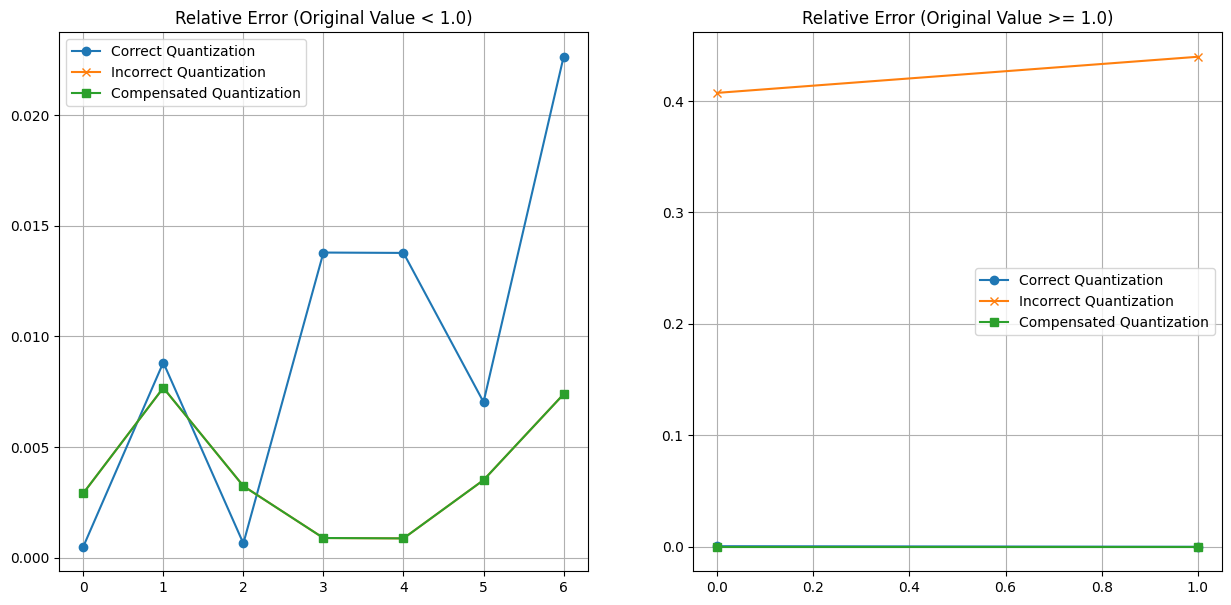

The mean relative error for correct quantization: 0.0075
The mean relative error for incorrect quantization: 0.0970
The mean relative error for compensated quantization: 0.0029


In [14]:
# 计算相对误差
correct_dequant_relative_error = (np.abs(p_fp32 - p_correct_dequantized) / p_fp32).flatten()
incorrect_dequant_relative_error = (np.abs(p_fp32 - p_incorrect_dequantized) / p_fp32).flatten()
compensated_dequant_relative_error = (np.abs(p_fp32 - p_compensated_dequantized) / p_fp32).flatten()

# 获取掩码
mask_less_than_1 = (p_fp32 < 1.0).flatten()
mask_greater_equal_1 = (p_fp32 >= 1.0).flatten()

# 分割误差数据
correct_err_lt_1 = correct_dequant_relative_error[mask_less_than_1]
incorrect_err_lt_1 = incorrect_dequant_relative_error[mask_less_than_1]
compensated_err_lt_1 = compensated_dequant_relative_error[mask_less_than_1]

correct_err_ge_1 = correct_dequant_relative_error[mask_greater_equal_1]
incorrect_err_ge_1 = incorrect_dequant_relative_error[mask_greater_equal_1]
compensated_err_ge_1 = compensated_dequant_relative_error[mask_greater_equal_1]

plt.figure(figsize=(15, 7))

# 绘制小于1的部分
plt.subplot(1, 2, 1)
plt.title("Relative Error (Original Value < 1.0)")
plt.plot(correct_err_lt_1, label="Correct Quantization", marker='o')
plt.plot(incorrect_err_lt_1, label="Incorrect Quantization", marker='x')
plt.plot(compensated_err_lt_1, label="Compensated Quantization", marker='s')
plt.legend()
plt.grid(True)

# 绘制大于等于1的部分
plt.subplot(1, 2, 2)
plt.title("Relative Error (Original Value >= 1.0)")
plt.plot(correct_err_ge_1, label="Correct Quantization", marker='o')
plt.plot(incorrect_err_ge_1, label="Incorrect Quantization", marker='x')
plt.plot(compensated_err_ge_1, label="Compensated Quantization", marker='s')
plt.legend()
plt.grid(True)

plt.show()

print(f"The mean relative error for correct quantization: {np.mean(correct_dequant_relative_error):.4f}")
print(f"The mean relative error for incorrect quantization: {np.mean(incorrect_dequant_relative_error):.4f}")
print(f"The mean relative error for compensated quantization: {np.mean(compensated_dequant_relative_error):.4f}")